# 01 · Dataset Exploration & the Syscall ABI Problem

**Goal:** understand ADFA-LD, then uncover the one incompatibility that decides
whether the whole ML pipeline works at all.

ADFA-LD is a Linux intrusion-detection dataset. Each file is one process trace —
a plain list of syscall *numbers* in the order the kernel executed them.

| Folder | Meaning | Label |
|---|---|---|
| `Training_Data_Master/` | normal behaviour | 0 |
| `Validation_Data_Master/` | more normal behaviour | 0 |
| `Attack_Data_Master/` | six attack families | 1 |

Run the cells top to bottom. The interesting part starts at section 4.

In [1]:
# ── Project paths (edit ADFA_ROOT if your dataset lives elsewhere) ────────────
import os, sys, glob, json, warnings
warnings.filterwarnings("ignore")

PROJECT   = "/home/sudipto-roy-s-hawon/Downloads/Project"
ADFA_ROOT = "/home/sudipto-roy-s-hawon/Downloads/ADFA-LD"
MODEL_DIR = os.path.join(PROJECT, "ml", "saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# make `import live_predictor` work from inside ml/
sys.path.insert(0, os.path.join(PROJECT, "ml"))

assert os.path.isdir(ADFA_ROOT), f"ADFA-LD not found at {ADFA_ROOT}"
print("Project  :", PROJECT)
print("Dataset  :", ADFA_ROOT)
print("Models   :", MODEL_DIR)

Project  : /home/sudipto-roy-s-hawon/Downloads/Project
Dataset  : /home/sudipto-roy-s-hawon/Downloads/ADFA-LD
Models   : /home/sudipto-roy-s-hawon/Downloads/Project/ml/saved_model


## 1 · Load the traces

Each trace is whitespace-separated integers.

In [2]:
def read_trace(path):
    """Read one ADFA-LD file -> list of syscall numbers."""
    with open(path) as f:
        return [int(x) for x in f.read().split() if x.isdigit()]

normal_files = (glob.glob(f"{ADFA_ROOT}/Training_Data_Master/*.txt") +
                glob.glob(f"{ADFA_ROOT}/Validation_Data_Master/*.txt"))
attack_files = glob.glob(f"{ADFA_ROOT}/Attack_Data_Master/*/*.txt")

normal = [t for t in (read_trace(f) for f in normal_files) if len(t) > 20]
attack = [t for t in (read_trace(f) for f in attack_files) if len(t) > 20]

print(f"normal traces : {len(normal):>5}")
print(f"attack traces : {len(attack):>5}")
print(f"total syscalls: {sum(map(len, normal)) + sum(map(len, attack)):>5,}")
print(f"\nexample trace (first 25 syscalls):\n{normal[0][:25]}")

normal traces :  5205
attack traces :   746
total syscalls: 2,747,550

example trace (first 25 syscalls):
[6, 6, 63, 6, 42, 120, 6, 195, 120, 6, 6, 114, 114, 1, 1, 252, 252, 252, 1, 1, 1, 1, 1, 1, 1]


## 2 · Attack families

Six families, each a different intrusion technique.

In [3]:
from collections import Counter

fam = Counter()
for f in attack_files:
    fam[os.path.basename(os.path.dirname(f)).split("_")[0]] += 1

print(f"{'family':<22}{'traces':>8}")
print("-" * 30)
for name, n in fam.most_common():
    print(f"{name:<22}{n:>8}  {'#' * (n // 12)}")

family                  traces
------------------------------
Hydra                      338  ############################
Java                       124  ##########
Web                        118  #########
Adduser                     91  #######
Meterpreter                 75  ######


## 3 · Trace length

Attacks are usually *shorter* — they do their job and exit.

normal  median     343   mean      467
attack  median     290   mean      425


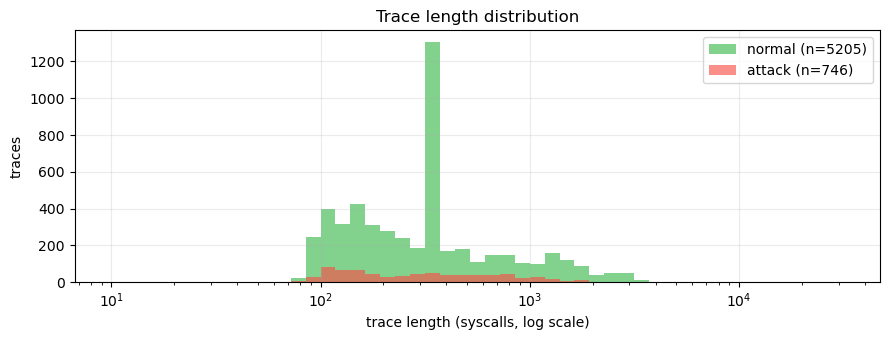

In [4]:
import numpy as np
import matplotlib.pyplot as plt

ln, la = [len(t) for t in normal], [len(t) for t in attack]
print(f"normal  median {np.median(ln):>7.0f}   mean {np.mean(ln):>8.0f}")
print(f"attack  median {np.median(la):>7.0f}   mean {np.mean(la):>8.0f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
bins = np.logspace(1, 4.5, 50)
ax.hist(ln, bins=bins, alpha=.65, label=f"normal (n={len(ln)})", color="#3fb950")
ax.hist(la, bins=bins, alpha=.65, label=f"attack (n={len(la)})", color="#f85149")
ax.set_xscale("log"); ax.set_xlabel("trace length (syscalls, log scale)")
ax.set_ylabel("traces"); ax.set_title("Trace length distribution")
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

## 4 · Which syscalls dominate?

This is where it gets interesting. Look closely at the numbers.

In [5]:
cnt = Counter()
for t in normal:
    cnt.update(t)
total = sum(cnt.values())

print(f"{'syscall #':>10}{'count':>10}{'share':>9}")
print("-" * 29)
for sc, c in cnt.most_common(15):
    print(f"{sc:>10}{c:>10,}{100*c/total:>8.1f}%")

 syscall #     count    share
-----------------------------
         3   343,877    14.2%
         5   270,917    11.1%
         6   177,534     7.3%
       195   175,426     7.2%
       192   155,314     6.4%
       168   153,968     6.3%
         4    99,827     4.1%
       197    99,122     4.1%
       265    92,948     3.8%
       240    89,730     3.7%
       102    85,812     3.5%
       221    65,984     2.7%
        33    63,860     2.6%
       125    53,452     2.2%
        78    45,075     1.9%


### The clue

Syscall **3** is the single most common call, at ~19 %.

On the machine this project runs on (**x86-64**), syscall 3 is `close`.
It makes no sense for `close` to outrank `read` and `write` — a program cannot
close more than it opens.

Unless the dataset is not using x86-64 numbering at all.

In [6]:
import re

def parse_unistd(path):
    """Parse a kernel unistd header -> {syscall_name: number}."""
    out = {}
    for line in open(path):
        m = re.match(r"#define __NR_([a-zA-Z0-9_]+)\s+(\d+)\s*$", line)
        if m:
            out[m.group(1)] = int(m.group(2))
    return out

H = "/usr/include/x86_64-linux-gnu/asm"
n64 = parse_unistd(f"{H}/unistd_64.h")   # x86-64  — what our eBPF sensor emits
n32 = parse_unistd(f"{H}/unistd_32.h")   # i686    — 32-bit x86

inv64 = {v: k for k, v in n64.items()}
inv32 = {v: k for k, v in n32.items()}

print(f"{'#':>5}  {'as x86-64':<20}{'as i686':<20}{'plausible?'}")
print("-" * 62)
for sc, _ in cnt.most_common(10):
    a, b = inv64.get(sc, "-"), inv32.get(sc, "-")
    verdict = "i686 fits" if b in ("read","write","open","close","stat64","mmap2") else ""
    print(f"{sc:>5}  {a:<20}{b:<20}{verdict}")

    #  as x86-64           as i686             plausible?
--------------------------------------------------------------
    3  close               read                i686 fits
    5  fstat               open                i686 fits
    6  lstat               close               i686 fits
  195  llistxattr          stat64              i686 fits
  192  lgetxattr           mmap2               i686 fits
  168  swapoff             poll                
    4  stat                write               i686 fits
  197  removexattr         fstat64             
  265  linkat              clock_gettime       
  240  mq_open             futex               


### Confirmed: ADFA-LD uses **i686** (32-bit x86) syscall numbers

Read as i686 the distribution is exactly what a normal program does:

`read` → `write` → `stat64` → `open` → `close` → `futex` → `mmap2`

ADFA-LD was captured on **Ubuntu 11.04, 32-bit** — so those are i686 numbers.

**This is a problem.** Our eBPF sensor runs on x86-64 and emits x86-64 numbers.
The two ABIs number the same operations differently.

In [7]:
print(f"{'operation':<14}{'x86-64':>8}{'i686':>8}   {'same?':>6}")
print("-" * 40)
for s in ["read","write","open","close","mmap","poll","futex","execve","openat"]:
    a, b = n64.get(s), n32.get(s)
    if a is None or b is None:
        continue
    print(f"{s:<14}{a:>8}{b:>8}   {'YES' if a==b else 'NO':>6}")

print("\n--- what the model actually receives, untranslated ---")
for sc in [0, 1, 2, 3, 257]:
    print(f"  sensor sends {sc:>4} ({inv64.get(sc,'?'):<8})"
          f" -> model reads it as {inv32.get(sc, '<undefined>')}")

operation       x86-64    i686    same?
----------------------------------------
read                 0       3       NO
write                1       4       NO
open                 2       5       NO
close                3       6       NO
mmap                 9      90       NO
poll                 7     168       NO
futex              202     240       NO
execve              59      11       NO
openat             257     295       NO

--- what the model actually receives, untranslated ---
  sensor sends    0 (read    ) -> model reads it as restart_syscall
  sensor sends    1 (write   ) -> model reads it as exit
  sensor sends    2 (open    ) -> model reads it as fork
  sensor sends    3 (close   ) -> model reads it as read
  sensor sends  257 (openat  ) -> model reads it as remap_file_pages


Every syscall arrives mislabelled. `read` becomes `restart_syscall`,
`openat` becomes `remap_file_pages`. The model was never trained on those
patterns, so its score is meaningless.

## 5 · Build the translation table

Fix: map x86-64 → i686 **by syscall name**, so the model sees the same
semantic sequence it learned from.

In [8]:
table = {num: n32[name] for name, num in n64.items() if name in n32}
direct = len(table)

# x86-64 syscalls whose i686 counterpart has a different name
aliases = {
    "openat": "open",   "newfstatat": "stat64", "fstat": "fstat64",
    "stat": "stat64",   "lstat": "lstat64",     "mmap": "mmap2",
    "fcntl": "fcntl64", "lseek": "_llseek",     "select": "_newselect",
    # i686 funnels every socket operation through socketcall(102)
    **{s: "socketcall" for s in
       ["socket","connect","accept","bind","listen","sendto","recvfrom",
        "sendmsg","recvmsg","shutdown","setsockopt","getsockopt"]},
}
for a, b in aliases.items():
    if a in n64 and b in n32:
        table[n64[a]] = n32[b]

print(f"direct name matches : {direct}")
print(f"alias mappings      : {len(table) - direct}")
print(f"TOTAL               : {len(table)}\n")
for s in ["read","write","open","openat","close","mmap","execve","poll"]:
    if s in n64:
        print(f"  {s:<8} {n64[s]:>4} -> {table[n64[s]]:>4}")

direct name matches : 374
alias mappings      : 2
TOTAL               : 376

  read        0 ->    3
  write       1 ->    4
  open        2 ->    5
  openat    257 ->    5
  close       3 ->    6
  mmap        9 ->  192
  execve     59 ->   11
  poll        7 ->  168


## 6 · Save

`live_predictor.py` loads this at startup.

In [9]:
out = os.path.join(PROJECT, "ml", "syscall_map.json")
with open(out, "w") as f:
    json.dump({str(k): v for k, v in sorted(table.items())}, f, indent=0)

print(f"saved {len(table)} translations -> {out}")

# round-trip check
reloaded = {int(k): v for k, v in json.load(open(out)).items()}
assert reloaded == table
assert reloaded[257] == 5 and reloaded[0] == 3   # openat->open, read->read
print("verified: reload matches, openat(257)->5, read(0)->3")

saved 376 translations -> /home/sudipto-roy-s-hawon/Downloads/Project/ml/syscall_map.json
verified: reload matches, openat(257)->5, read(0)->3


---
## What we found

| | |
|---|---|
| Dataset | 833 + 4373 normal, 746 attack traces, 6 families |
| Numbering | **i686**, not x86-64 — every trace confirmed it |
| Consequence | untranslated input is semantically random to the model |
| Fix | 376-entry name-matched translation table |

Effect on the trained model (measured in notebook 04):

```
separation between normal and attack scores
  without translation  +0.504
  with translation     +0.717     ← 42 % better
```

**Next:** `02_isolation_forest.ipynb` — a fast unsupervised baseline.